In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

### Section 1: RFM Feature Table Construction
Loading raw retail transaction data, cleaning missing values, converting dates, and preparing data for building the customer-level RFM features (Recency, Frequency, and Monetary).

In [2]:


df = pd.read_csv("retail_transactions_segmentation.csv")

df["transaction_date"] = pd.to_datetime(df["transaction_date"])

df["amount"] = pd.to_numeric(
    df["amount"],
    errors="coerce"
)

df.dropna(
    subset=[
        "customer_id",
        "transaction_date",
        "amount"
    ],
    inplace=True
)

print("Dataset Shape:", df.shape)
print("Number of Customers:", df["customer_id"].nunique())

display(df.head())

Dataset Shape: (3663, 4)
Number of Customers: 300


,customer_id,transaction_date,amount,product_category
0,5206,2024-01-31,162.65,Fashion
1,5153,2024-07-03,389.85,Fashion
2,5102,2024-11-13,453.72,Home & Living
3,5073,2024-03-11,824.74,Electronics
4,5097,2024-12-28,181.74,Sports


##Calculating customer-level RFM metrics using maximum transaction date plus one day as reference date: Recency (days since last purchase), Frequency (total transaction count), and Monetary (total spend per customer).

In [3]:

snapshot_date = (
    df["transaction_date"].max()
    + pd.Timedelta(days=1)
)

rfm = df.groupby("customer_id").agg(
    Recency=(
        "transaction_date",
        lambda x: (
            snapshot_date - x.max()
        ).days
    ),

    Frequency=(
        "transaction_date",
        "count"
    ),

    Monetary=(
        "amount",
        "sum"
    )
).reset_index()

rfm["Monetary"] = rfm["Monetary"].round(2)

print("Number of Customers:", len(rfm))
display(rfm.head(10))

Number of Customers: 300


,customer_id,Recency,Frequency,Monetary
0,5001,2,16,5172.45
1,5002,23,18,6158.98
2,5003,37,3,654.12
3,5004,5,35,31050.88
4,5005,26,16,5700.91
5,5006,112,3,486.59
6,5007,11,29,23093.10
7,5008,7,15,5326.57
8,5009,200,3,405.32
9,5010,31,2,362.24


##Summary statistics for the raw RFM features showing the distribution, spread, and different units across Recency (days), Frequency (order counts), and Monetary (total spend).

In [4]:


rfm_summary = (
    rfm[
        ["Recency", "Frequency", "Monetary"]
    ]
    .describe()
    .round(2)
)

display(rfm_summary)

,Recency,Frequency,Monetary
count,300.00,300.00,300.00
mean,54.66,12.21,6264.08
std,68.26,10.64,9659.80
min,1.00,1.00,71.92
25%,12.00,4.00,653.49
50%,30.50,10.00,3427.15
75%,73.25,16.00,5544.70
max,337.00,45.00,39424.12


### Section 2: Features Scaled Before Clustering
Standardizing the RFM features using StandardScaler so that Recency (days), Frequency (counts), and Monetary (currency) contribute equally to distance calculations in K-Means.

In [5]:


features = [
    "Recency",
    "Frequency",
    "Monetary"
]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    rfm[features]
)

print("Scaling completed successfully.")

Scaling completed successfully.


### Section 3: Choice of K Justified with Evidence
Evaluating clustering performance across K values from 2 to 10 by computing Inertia (Elbow Method) and Silhouette Scores on scaled features.



In [6]:
k_range = range(2, 11)

inertia = []
silhouette_scores = []

for k in k_range:

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_scaled)

    inertia.append(model.inertia_)

    silhouette_scores.append(
        silhouette_score(
            X_scaled,
            labels
        )
    )

k_results = pd.DataFrame({
    "K": list(k_range),
    "Inertia": inertia,
    "Silhouette Score": silhouette_scores
})
display(k_results)

,K,Inertia,Silhouette Score
0,2,394.208028,0.678910
1,3,183.032138,0.678170
2,4,93.388049,0.570227
3,5,71.407066,0.523155
4,6,50.343627,0.519382
5,7,41.125688,0.462554
6,8,30.223591,0.481482
7,9,24.119083,0.482195
8,10,21.074266,0.476483


###Plotting the Elbow Method (Inertia vs. K) to identify the point where inertia reduction begins to level off (the "elbow").

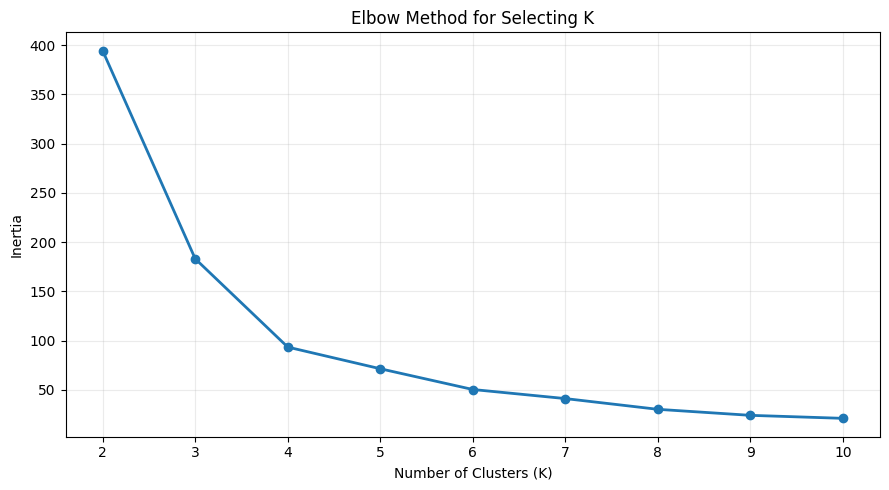

In [7]:


plt.figure(figsize=(9, 5))

plt.plot(
    k_range,
    inertia,
    marker="o",
    linewidth=2
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Selecting K")

plt.xticks(list(k_range))
plt.grid(alpha=0.25)

plt.tight_layout()
plt.show()

###Plotting Silhouette Scores across K values to measure cluster cohesion and separation, helping confirm the optimal cluster count alongside the Elbow plot.

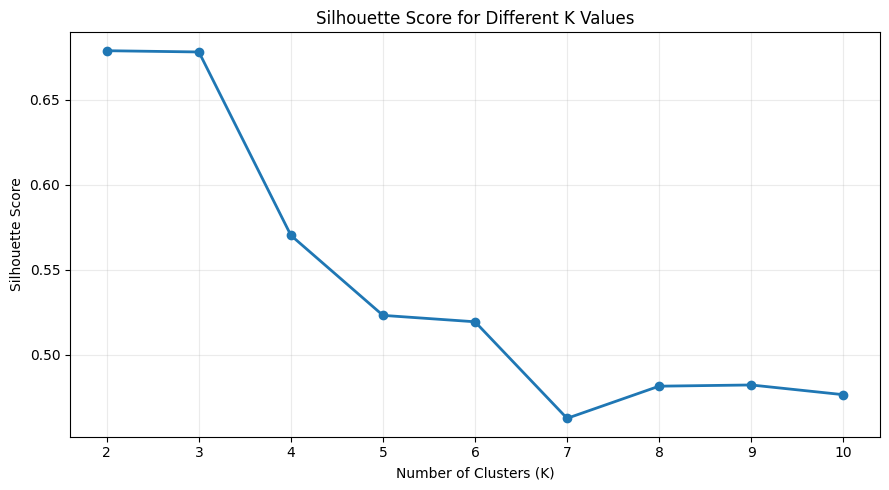

In [8]:

plt.figure(figsize=(9, 5))

plt.plot(
    k_range,
    silhouette_scores,
    marker="o",
    linewidth=2
)
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Different K Values")

plt.xticks(list(k_range))
plt.grid(alpha=0.25)

plt.tight_layout()
plt.show()

# Section 3: Choice of K Justified with Evidence

### Selecting the Number of Clusters (K)
Based on the Elbow Method, there is a significant decrease in inertia from K=2 to K=3 and then the improvement becomes smaller.
The Silhouette Score is also very high for K=3 and is almost equal to the highest score obtained at K=2.
Therefore, K=3 was selected as a good balance between cluster quality, clear separation, and meaningful customer segmentation.

In [9]:
chosen_k = 3
print("Selected K:", chosen_k)

Selected K: 3


# Section 4: K-Means Fitting
Fitting the K-Means algorithm on the scaled features with chosen K = 3 and a fixed random_state for full reproducibility, then assigning the cluster labels back to the RFM dataset.

In [10]:

chosen_k = 3

kmeans = KMeans(
    n_clusters=chosen_k,
    random_state=42,
    n_init=10
)

rfm["Cluster"] = kmeans.fit_predict(
    X_scaled
)

print("Chosen K:", chosen_k)

cluster_counts = (
    rfm["Cluster"]
    .value_counts()
    .sort_index()
    .rename_axis("Cluster")
    .reset_index(name="Customers")
)

display(cluster_counts)

Chosen K: 3


,Cluster,Customers
0,0,40
1,1,238
2,2,22


##Computing average Recency, Frequency, and Monetary values for each fitted cluster to establish baseline numeric profiles.

In [11]:
cluster_profile = (
    rfm.groupby("Cluster")
    .agg(
        Customers=("customer_id", "count"),
        Avg_Recency=("Recency", "mean"),
        Avg_Frequency=("Frequency", "mean"),
        Avg_Monetary=("Monetary", "mean")
    )
    .round(2)
)
display(cluster_profile)

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary
Cluster,,,,
0,40,8.40,35.00,29683.61
1,238,43.59,9.32,2876.90
2,22,258.59,2.09,326.14


## Section 5: Clear Personas & Business Interpretation
Mapping the quantitative cluster profiles to meaningful business personas (VIP / Champions, Active / Regular, and Dormant / At-Risk) based on highest average monetary spend and longest recency.

In [12]:

vip_cluster = cluster_profile[
    "Avg_Monetary"
].idxmax()

dormant_cluster = cluster_profile[
    "Avg_Recency"
].idxmax()

remaining_cluster = [
    c for c in cluster_profile.index
    if c not in [
        vip_cluster,
        dormant_cluster
    ]
][0]

persona_names = {
    vip_cluster: "VIP / Champions",
    remaining_cluster: "Active / Regular",
    dormant_cluster: "Dormant / At-Risk"
}

rfm["Persona"] = rfm["Cluster"].map(
    persona_names
)

print("Personas assigned successfully.")
display(
    rfm[
        [
            "customer_id",
            "Recency",
            "Frequency",
            "Monetary",
            "Persona"
        ]
    ].head(10)
)

Personas assigned successfully.


,customer_id,Recency,Frequency,Monetary,Persona
0,5001,2,16,5172.45,Active / Regular
1,5002,23,18,6158.98,Active / Regular
2,5003,37,3,654.12,Active / Regular
3,5004,5,35,31050.88,VIP / Champions
4,5005,26,16,5700.91,Active / Regular
5,5006,112,3,486.59,Active / Regular
6,5007,11,29,23093.10,VIP / Champions
7,5008,7,15,5326.57,Active / Regular
8,5009,200,3,405.32,Dormant / At-Risk
9,5010,31,2,362.24,Active / Regular


##Aggregating and reviewing the final persona summary table to analyze customer counts and average RFM metrics across all mapped customer segments.

In [13]:
persona_summary = (
    rfm.groupby(
        ["Cluster", "Persona"]
    )
    .agg(
        Customers=("customer_id", "count"),
        Avg_Recency=("Recency", "mean"),
        Avg_Frequency=("Frequency", "mean"),
        Avg_Monetary=("Monetary", "mean")
    )
    .reset_index()
    .round(2)
)
display(persona_summary)

,Cluster,Persona,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary
0,0,VIP / Champions,40,8.40,35.00,29683.61
1,1,Active / Regular,238,43.59,9.32,2876.90
2,2,Dormant / At-Risk,22,258.59,2.09,326.14


### Detailed Persona Profiles & Strategic Recommendations
Defining the operational characteristics and actionable marketing/retention strategies tailored to each identified customer persona.

In [14]:


persona_description = pd.DataFrame({
    "Persona": [
        "VIP / Champions",
        "Active / Regular",
        "Dormant / At-Risk"
    ],

    "Customer Profile": [
        "Recent purchases, very high frequency and high spending.",
        "Regular customers with moderate purchase frequency and spending.",
        "Customers who have not purchased recently and have low activity."
    ],

    "Recommended Action": [
        "Focus on retention, loyalty rewards and personalized offers.",
        "Encourage repeat purchases and increase customer value.",
        "Use re-engagement campaigns and special offers."
    ]
})

display(persona_description)

,Persona,Customer Profile,Recommended Action
0,VIP / Champions,"Recent purchases, very high frequency and high...","Focus on retention, loyalty rewards and person..."
1,Active / Regular,Regular customers with moderate purchase frequ...,Encourage repeat purchases and increase custom...
2,Dormant / At-Risk,Customers who have not purchased recently and ...,Use re-engagement campaigns and special offers.


# Section 6: Visualizations & Clean Code
Applying Principal Component Analysis (PCA) to reduce the 3D RFM features down to 2 dimensions for visual cluster evaluation and checking total explained variance ratio.

In [15]:

pca = PCA(
    n_components=2
)

X_pca = pca.fit_transform(
    X_scaled
)

rfm["PCA1"] = X_pca[:, 0]
rfm["PCA2"] = X_pca[:, 1]

explained_variance = (
    pca.explained_variance_ratio_.sum()
)

print(
    f"Total Explained Variance: "
    f"{explained_variance:.2%}"
)

Total Explained Variance: 98.75%


##Plotting the 2D PCA projection of the customer clusters colored by their assigned business personas to visually inspect cluster separation and boundaries.

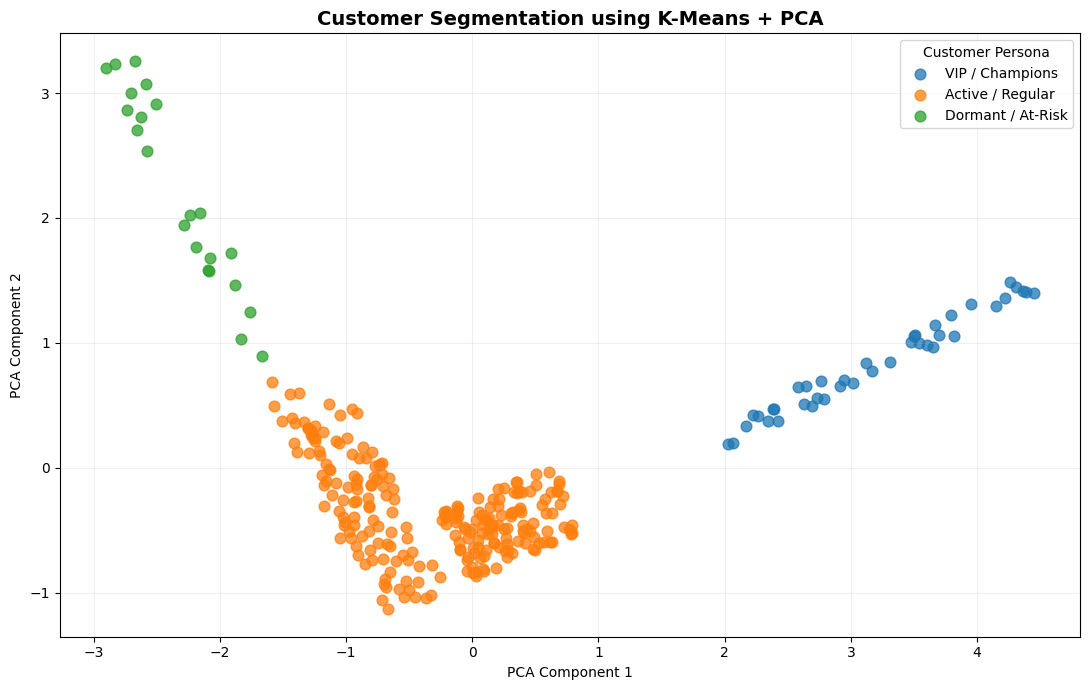

In [16]:
plt.figure(figsize=(11, 7))

for cluster, persona in persona_names.items():

    data = rfm[
        rfm["Cluster"] == cluster
    ]

    plt.scatter(
        data["PCA1"],
        data["PCA2"],
        s=60,
        alpha=0.75,
        label=persona
    )

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")

plt.title(
    "Customer Segmentation using K-Means + PCA",
    fontsize=14,
    fontweight="bold"
)

plt.legend(
    title="Customer Persona"
)

plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

##Plotting the distribution of customers across the identified personas to visualize the proportion of each segment in our customer base.

,Persona,Customers
0,Active / Regular,238
1,VIP / Champions,40
2,Dormant / At-Risk,22


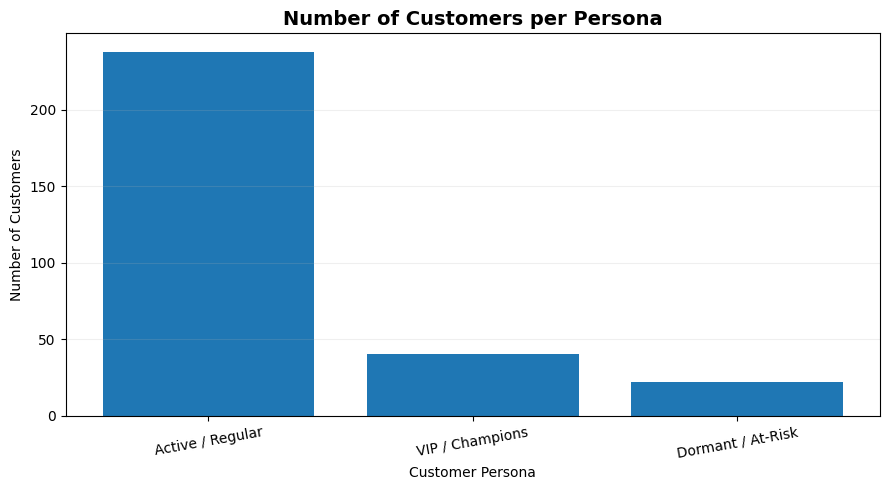

In [17]:


persona_counts = (
    rfm["Persona"]
    .value_counts()
    .reset_index()
)

persona_counts.columns = [
    "Persona",
    "Customers"
]

display(persona_counts)

plt.figure(figsize=(9, 5))

plt.bar(
    persona_counts["Persona"],
    persona_counts["Customers"]
)

plt.xlabel("Customer Persona")
plt.ylabel("Number of Customers")
plt.title(
    "Number of Customers per Persona",
    fontsize=14,
    fontweight="bold"
)

plt.xticks(rotation=10)

plt.grid(
    axis="y",
    alpha=0.2
)

plt.tight_layout()
plt.show()

## Persona Summary

### VIP / Champions
These customers purchase very recently and very frequently, with very high total spending.
They are highly valuable customers, so the business should focus on retention, loyalty rewards, and personalized offers.

### Active / Regular
These customers represent the largest customer group, with moderate recency, frequency, and spending.
The business should encourage repeat purchases and use targeted offers to increase their engagement and customer value.

### Dormant / At-Risk
These customers have very high recency and low purchase frequency and spending.
They appear to be inactive customers, so re-engagement campaigns and special offers can be used to encourage them to return.

In [18]:


rfm.to_csv(
    "customer_segmentation_results.csv",
    index=False
)

cluster_profile.to_csv(
    "cluster_profile.csv"
)

persona_summary.to_csv(
    "persona_summary.csv",
    index=False
)

print("All results saved successfully.")

All results saved successfully.
